# NPUWattch hands-on — 3. Timeloop: Gemmini-like vs. NVDLA-like

Two designs, two workloads, four runs. Both designs follow the
specifications in Table IV of the NPUWattch paper: int8 operands, int32
accumulation, LPDDR4 DRAM, 7 nm.

| | `gemmini_like` | `nvdla_like` |
| --- | --- | --- |
| Compute | 16×16 weight-stationary systolic array (256 MACs) | 8 MAC cells × 8 multipliers, adder-tree reduction (64 MACs) |
| On-chip buffer | 256 KB scratchpad + 64 KB accumulator | 64 KB CBUF + 1 KB CACC |
| Post-processing | none | SDP: bias, batch norm, ReLU, requantization |

The workloads are seven representative ResNet-50 layers and one Llama-3-8B
decoder block (prefill with 512 tokens, and decode of one token).


In [1]:
import sys; sys.path.insert(0, ".")
from tutorial_helpers import *
import pandas as pd
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 60)
print("npuwattch:", npuwattch_binary())

npuwattch: /home/KNUEEhdd1/ys_knu/kmk/miniforge3/envs/npuwattch/bin/npuwattch


## 1. Run all four

Each run is a few seconds. We keep the headline numbers of each in one table.

In [2]:
runs = {
    "Gemmini / ResNet-50": example("timeloop/gemmini_like/resnet50"),
    "NVDLA / ResNet-50":   example("timeloop/nvdla_like/resnet50"),
    "Gemmini / Llama-3-8B": example("timeloop/gemmini_like/llama3_8b"),
    "NVDLA / Llama-3-8B":   example("timeloop/nvdla_like/llama3_8b"),
}
texts, rows = {}, []
for label, ex in runs.items():
    texts[label] = run(ex)
    rows.append(summary_row(report(ex), label))
summary = pd.DataFrame(rows)
display(summary.drop(columns="total_pJ"))

,design / workload,total energy,DRAM share %,area mm²,avg power,pJ / MAC
0,Gemmini / ResNet-50,1.32e+03 µJ,38.6,0.423,316 mW,2.49
1,NVDLA / ResNet-50,1.22e+03 µJ,58.1,0.088,91.2 mW,2.30
2,Gemmini / Llama-3-8B,3.1e+05 µJ,46.5,0.423,673 mW,2.72
3,NVDLA / Llama-3-8B,1.02e+06 µJ,89.8,0.088,569 mW,8.95


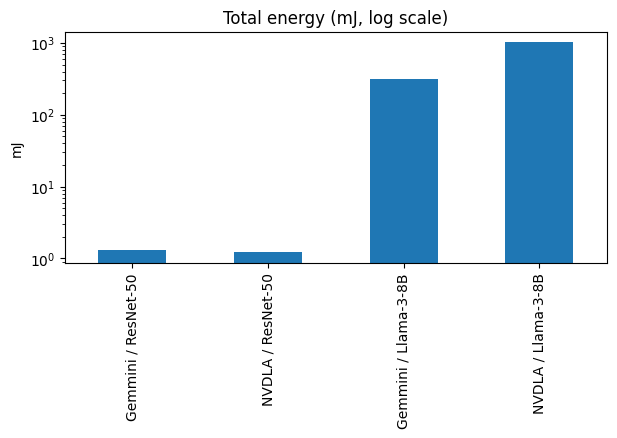

In [3]:
ax = summary.set_index("design / workload")["total_pJ"].div(1e9).plot.bar(figsize=(7, 3), legend=False, logy=True,
                                                                    title="Total energy (mJ, log scale)")
ax.set_xlabel(""); ax.set_ylabel("mJ");

## 2. The winner flips

Expected result (7 nm, 1 GHz, LPDDR4 at 8 pJ/bit):

| | Gemmini-like | NVDLA-like |
| --- | --- | --- |
| ResNet-50, total | 1.32 mJ | **1.22 mJ** |
| Llama-3-8B block, total | **310 mJ** | 1021 mJ |
| Area | 0.42 mm² | 0.09 mm² |

For ResNet-50, the NVDLA-like design wins: its datapath is cheaper, with no
per-PE partial-sum register. For the Llama block, the Gemmini-like design uses
about three times less energy. Neither design writes partial sums to memory, so
the accumulator size decides how often the inputs of a long reduction have to
be fetched again. The Gemmini-like accumulator holds 64 KB; the NVDLA-like
CACC holds 1 KB. Look at the DRAM share column in the table above to see this.

The better design depends on the workload, and the energy report is what tells
you which one.

## 3. A block Timeloop never saw: the SDP

The NVDLA-like design has a post-processing unit (SDP) that handles bias,
batch norm, ReLU, and requantization. Timeloop has no model of it, so it does
not appear in the stats. NPUWattch charges it anyway, through two files in
`timeloop/nvdla_like/`.

In [4]:
print("--- user_components.yaml (the SDP entry) ---")
show_file(example("timeloop/nvdla_like/user_components.yaml"))
print()
print("--- stats_map.yaml ---")
show_file(example("timeloop/nvdla_like/stats_map.yaml"))

--- user_components.yaml (the SDP entry) ---
# ============================================================================
#  User component library of the NVDLA-like design
# ============================================================================
# A user component is a block that NPUWattch has no model for. You give its
# cost in this file: the area, and the energy of each action. NPUWattch does
# not calculate these values.
#
# This file is an INPUT of the run. NPUWattch reads `user_components.yaml`
# from the directory of the architecture file, or the file that you give with
# --user-components.
#
# This file has two entries:
#   nvdla_sdp               USED by arch.yaml (component `sdp`). Measured
#                           values, see below.
#   example_68000_cpu_core  AN EXAMPLE. No design uses it, thus each run shows
#                           the message NW-2116 ("... is in the library,
#                           but the run does not use it").
#
# How a design uses an

- `user_components.yaml` gives the SDP's area, leakage, and the energy of its
  two actions, measured at 7 nm. In `arch.yaml`, the `sdp` component carries
  the attribute `user_component: nvdla_sdp`, which points at this entry.
- `stats_map.yaml` gives it activity. Every DRAM write is one output element
  leaving the chip, and each element passes through the SDP once, so each
  DRAM write also charges one `process` action on the SDP. (The `count: 8`
  is because a DRAM write here is a 64-bit word that holds eight int8
  elements.)

In the component table the SDP shows up with `user` in the `model` column:

In [5]:
df = components_df(report(example("timeloop/nvdla_like/resnet50")))
display(df)
show_messages(texts["NVDLA / ResNet-50"], kinds=("INFO",))

,component,class,model,instances,energy,share %,area
0,system_top_level.DRAM,hbm,const,1,708 µJ,58.1,n/a
1,system_top_level.nvdla.mac_cell.lane.mac,intmac,cal,64,376 µJ,30.9,70.4
2,system_top_level.nvdla.cacc,sram,cal,1,38.5 µJ,3.2,1.14e+03
3,system_top_level.nvdla.mac_cell.lane.input_reg,regfile,cal,64,32 µJ,2.6,4.06
4,system_top_level.nvdla.cbuf,sram,cal,1,25.5 µJ,2.1,7.97e+04
5,system_top_level.nvdla.sdp,nvdla_sdp,user,1,24.1 µJ,2.0,1.94e+03
6,system_top_level.nvdla.mac_cell.lane.weight_reg,regfile,cal,64,14.4 µJ,1.2,4.06


INFO (NW-1026): Harness mode: timeloop
INFO (NW-1301): NPUWattch builds the description database from ../arch.yaml.
INFO (NW-1303): The description database has 7 components with 196 instances in total.
INFO (NW-1001): Instance hierarchy (declared in the Accelergy description):
INFO (NW-7403): system_top_level.DRAM (DRAM type LPDDR4): 8 pJ/bit from the shipped table lpddr4.yml.
INFO (NW-7301): system_top_level.DRAM (hbm): NPUWattch ignores the Accelergy attribute(s) datawidth.
INFO (NW-7109): system_top_level.nvdla.sdp: the user component library entry 'nvdla_sdp' gives the cost, not the class 'dummy_storage'.
INFO (NW-7306): system_top_level.nvdla.cbuf (sram): depth 8192 is the total of 16 banks, so mem_depth_per_bank is 512 (64 KB total).
INFO (NW-7307): system_top_level.nvdla.cbuf (sram): no port count is declared, so NPUWattch uses one shared read-write port.
INFO (NW-7308): system_top_level.nvdla.cbuf (sram): bandwidth 16 words/cycle (8 words per access) gives up to 2 bank accesse

The SDP is about 2% of the ResNet-50 energy and well under 1% of the Llama
energy. Small, but now it is in the breakdown instead of missing from it.

The INFO line `NW-7222`, `Stats level 'DRAM' charges more than one
component: ...`, confirms what the stats map did.

## Messages you will see

**Every time.** The same INFO lines as in notebook 2 (`NW-7307`, `NW-2116`,
`NW-7101`), plus, for the NVDLA-like design, two INFO lines: `NW-7109` for
the `user_component` attribute and `NW-7222` for the stats-map fan-out. No
WARNING lines.

**If something looks wrong.** The table at the end of notebook 2 applies here
too. One more case for designs with a user component:

| What you see | What it means | What to do |
| --- | --- | --- |
| `WARNING (NW-8302): ...: User component 'X': the values are for 7nm, but the run is at 5nm.` | Your entry was measured at another node than the run | State the node your numbers belong to in `reference:`; NPUWattch uses them as given and tells you about the difference. We are preparing to support scaling user components across nodes in a future release. |

Next: `04_your_own_data.ipynb`.
